# Module 2 — Metrics Frameworks: North Star, HEART, AARRR, OKRs

Part of the Product Analytics Playbook. Program and progress: [CURRICULUM.md](CURRICULUM.md).

## Why you're here: what this module is for

- "What metrics would you track?" is a standard product-analyst interview question, and an everyday one on the job. A **metrics framework** is a ready-made structure for answering it: a short list of metric types to fill in, so nothing important is forgotten.
- There are several well-known frameworks. Each one is built for a different question, and each one misses something.
- This module applies four of them to the same store, with real numbers, so their differences are visible side by side.

**What this module produces:**
1. Each framework (North Star, HEART, AARRR, OKRs) filled in for this store, with numbers from the data, and "no data" stated where the log can't measure something.
2. A recap of a primary-metric-plus-guardrails setup built in an earlier project.
3. One table comparing the frameworks: what each is for, and what each misses.

## From the curriculum

> ## <u>Module 2 — Metrics Frameworks: North Star, HEART, AARRR, OKRs</u>
>
> **Concepts**
> - North Star Metric: one metric for the value customers get, plus 3–5 input
>   metrics teams can move
> - HEART (Happiness, Engagement, Adoption, Retention, Task success) with
>   Goals → Signals → Metrics (Google's user-centred framework)
> - AARRR, the "pirate metrics" (Acquisition, Activation, Retention, Referral,
>   Revenue): a lifecycle funnel of metrics
> - OKRs (Objectives and Key Results): how a framework's metrics become
>   quarterly targets
> - Primary metric plus guardrails: the experiment-time view (the OEC, Overall
>   Evaluation Criterion, in the A/B Testing Playbook)
> - What each framework is for, what each misses, and when to pick which
>
> **Why it matters**
> "What metrics would you track for X?" is a standard product-analyst
> interview question. Frameworks give a structured answer and expose blind
> spots. Without one, teams pick metrics with blind spots they don't notice, and
> optimise the wrong thing.
>
> **Worked example**
> Each framework applied to the cosmetics-store event log with real numbers: a North Star
> candidate and its input tree; HEART with "no data" cells
> (no Happiness data exists); AARRR stages computed where the log supports them
> (no Acquisition source, no Referral event). Recapped as one example: the
> Product Analytics Case Study's applied primary metric (Week-2 Activation Rate,
> 61.7%) plus three guardrails
> ([`05_Metrics_Framework_and_Synthesis.ipynb`](https://github.com/omri-sabag83/Product-Analytics-Case-Study/blob/main/05_Metrics_Framework_and_Synthesis.ipynb),
> section "Framework summary").
>
> **Resources**
> - [Measuring the User Experience on a Large Scale: User-Centered Metrics for Web Applications](https://research.google.com/pubs/archive/36299.pdf)
>   (Rodden, Hutchinson & Fu, CHI 2010, ~25 min, verified): the original HEART
>   paper.
> - [North Star Playbook: About the North Star Framework](https://amplitude.com/books/north-star/about-north-star-framework)
>   (Amplitude, ~20 min, verified).
> - [Startup Metrics for Pirates](https://www.slideshare.net/slideshow/startup-metrics-for-pirates-presentation/629833)
>   (Dave McClure, 2007 slides, ~10 min, verified): the original AARRR deck.
>
> **Exercise type:** framework selection, fully worked: given three product
> scenarios, choose and fill a framework, and name what it can't see.
>
> **Interview angle:** "What would be the North Star for product X?" / "What
> metrics would you track for this feature launch?"

## Lesson

### Words used in this module

- A **metric** is a number computed the same way every time, e.g. "orders per month".
- An **input metric** is a metric a team can influence directly, which pushes a bigger metric up or down.
- A **window** is a fixed time span after a starting point, e.g. "within 7 days of a user's first event".

### The four frameworks

**1. North Star Metric (Amplitude's framework).** One metric that measures the value customers get from the product, plus 3 to 5 input metrics that drive it. Its job: point every team at the same number.

**2. HEART (Google).** Five metric types for the user experience: **H**appiness (how users feel, usually from surveys), **E**ngagement (how much they use the product), **A**doption (how many new users start using it), **R**etention (how many come back) and **T**ask success (how often users complete what they came to do). Each type is filled in three steps: a **goal** (what we want), a **signal** (what user behaviour would show it) and a **metric** (the number that measures the signal). Its job: measure the experience of a product or feature.

**3. AARRR, the "pirate metrics" (Dave McClure).** Five stages of a customer's life: **A**cquisition (they arrive), **A**ctivation (they have a first good experience), **R**etention (they come back), **R**eferral (they bring others) and **R**evenue (they pay). Its job: find the stage where most customers are lost.

**4. OKRs (Objectives and Key Results).** Not a set of metrics, but a way to set goals with them. An **objective** is a goal in words ("make first-time visitors into buyers"). Each **key result** is a metric with a starting value, a target and a deadline. Its job: turn a framework's metric into a target for a quarter.

**One more setup, for experiments: a primary metric plus guardrails.** One metric decides whether a change worked (the **primary metric**), and a few others must not get worse (the **guardrails**). The A/B Testing Playbook covers it in Module 4 ([`04_experiment_design.ipynb`](https://github.com/omri-sabag83/A-B-Testing-Playbook/blob/main/04_experiment_design.ipynb), section "Primary, secondary, and guardrail metrics — and the OEC"). Part 5 below recaps one built in an earlier project.

### Part 0 — The monthly building blocks, and what the data can't measure

All four frameworks are filled from the same few monthly numbers, computed below through the semantic layer from Module 1. Definitions:

- **active users:** users with at least one event in the month
- **buyers:** users with at least one order in the month
- **orders:** orders in the month (Module 1's rebuilt orders)
- **new users:** users whose first event in the data falls in that month

**Limits of the data, before any number:**
1. **"New user" means first seen *in this data*, which starts on 1 October 2019.** So in October every user looks new, including any earlier customers; new-user numbers are reported from November only. The same problem continues, more weakly, in later months: a customer who skipped October first appears in November and is counted as new there. So the "new" group is most mixed with older customers in November, and the "returning" group grows each month partly because there are more earlier months to look back on.
2. **Windows cut short at the end.** "Bought within 7 days of the first event" can't be measured for users first seen after 22 February 2020 (the data ends on 29 February), so they are left out. "Active again next month" can't be measured for February.
3. **No data at all** for some framework parts: there is no survey (so no Happiness), no traffic source (so no Acquisition channels) and no referral event (so no Referral).
4. As in every module, counts are for the 10% sample of users; rates need no scaling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from common import connect, query, metric, show, BLUE, ORANGE, AQUA, GREY

con = connect()
months = ["2019-10", "2019-11", "2019-12", "2020-01", "2020-02"]
month_end = {"2019-10": "2019-10-31", "2019-11": "2019-11-30", "2019-12": "2019-12-31",
             "2020-01": "2020-01-31", "2020-02": "2020-02-29"}

blocks = pd.DataFrame({m: {name: metric(con, name, m + "-01", month_end[m])
                           for name in ["active_users", "buyers", "orders", "new_users"]}
                       for m in months}).T
blocks.index.name = "month"
blocks = blocks.astype(int)
blocks.loc["2019-10", "new_users"] = -1   # not measurable: the data starts this month
show(blocks.apply(lambda col: col.map(lambda v: "n/a" if v == -1 else f"{v:,}")).reset_index())

month    active_users  buyers  orders  new_users
2019-10        40,098   2,445   2,841        n/a
2019-11        36,857   3,147   3,687     31,421
2019-12        37,167   2,533   2,907     30,136
2020-01        41,105   2,809   3,268     33,029
2020-02        38,943   2,512   2,961     29,586


**Observation:** each month, 36,857 to 41,105 sampled users are active, of whom 2,445 to 3,147 buy. November has the most buyers (3,147) and orders (3,687).

**Observation:** from November to February, 29,586 to 33,029 users a month are first seen in the data. In November that is 31,421 of 36,857 active users (31,421 ÷ 36,857 = 85%); this share is inflated in the early months (limit 1).

### Part 1 — North Star Metric

**Step 1: choose the North Star.** It should count the value customers get, not just activity. For a shop, the value is a completed purchase, so the candidate is **monthly orders**. Two alternatives, and why not:
- **monthly revenue** mixes value with price: an order of cheap items counts less than one of expensive items, though both customers got what they wanted. (Module 8 covers revenue.)
- **monthly active users** counts visits, not value: a user who browses and leaves counts the same as one who buys.

**Step 2: break it into input metrics.** Monthly orders can be written exactly as three factors multiplied:

orders = active users × (buyers ÷ active users) × (orders ÷ buyers)

This is exact because "active users" and "buyers" cancel out. Each factor is an input a team can work on:
- **active users:** bring people to the store (marketing)
- **payer rate** = buyers ÷ active users: turn visitors into buyers (product pages, checkout)
- **orders per buyer:** get buyers to order again within the month (reminders, loyalty)

**Step 3: compute the tree for every month.** The North Star together with its inputs is called a **metric tree**: the North Star at the top, and the inputs that multiply into it as its branches.

In [2]:
tree = pd.DataFrame({
    "active users": blocks["active_users"],
    "payer rate %": (blocks["buyers"] / blocks["active_users"] * 100),
    "orders per buyer": blocks["orders"] / blocks["buyers"],
    "orders (North Star)": blocks["orders"],
})
tree["check: product of the 3 inputs"] = tree["active users"] * tree["payer rate %"] / 100 * tree["orders per buyer"]
show(tree.round(2).assign(**{"active users": tree["active users"].map("{:,}".format),
                             "orders (North Star)": tree["orders (North Star)"].map("{:,}".format),
                             "check: product of the 3 inputs": tree["check: product of the 3 inputs"].map("{:,.0f}".format),
                             "payer rate %": tree["payer rate %"].map("{:.2f}".format),
                             "orders per buyer": tree["orders per buyer"].map("{:.3f}".format)}).reset_index())

month    active users  payer rate %  orders per buyer  orders (North Star)  check: product of the 3 inputs
2019-10        40,098          6.10             1.162                2,841                           2,841
2019-11        36,857          8.54             1.172                3,687                           3,687
2019-12        37,167          6.82             1.148                2,907                           2,907
2020-01        41,105          6.83             1.163                3,268                           3,268
2020-02        38,943          6.45             1.179                2,961                           2,961


**Reading the November row, with the exact counts** (36,857 active users, 3,147 buyers, 3,687 orders):

36,857 × (3,147 ÷ 36,857) × (3,687 ÷ 3,147) = 3,687 orders

The "check" column repeats this multiplication for every month and equals the orders column each time.

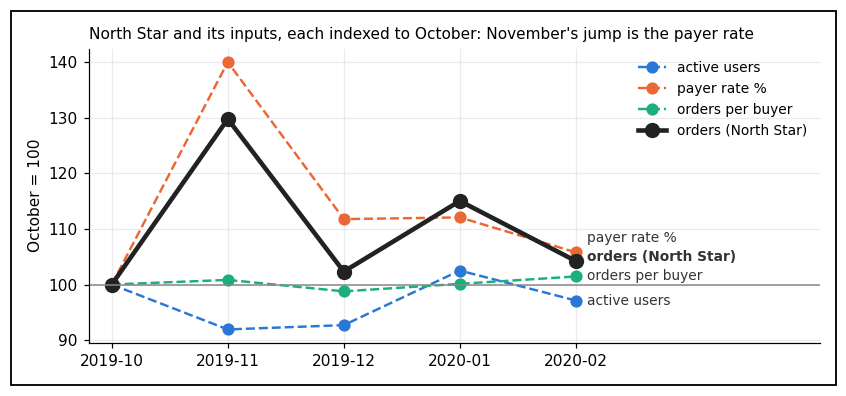

indexed values (October = 100):
month    active users  payer rate %  orders per buyer  orders (North Star)
2019-10         100.0         100.0             100.0                100.0
2019-11          91.9         140.0             100.8                129.8
2019-12          92.7         111.8              98.8                102.3
2020-01         102.5         112.1             100.1                115.0
2020-02          97.1         105.8             101.4                104.2


In [3]:
cols = ["active users", "payer rate %", "orders per buyer", "orders (North Star)"]
index = tree[cols] / tree[cols].iloc[0] * 100
fig, ax = plt.subplots(figsize=(7.5, 3.4))
x = range(len(index))
for col, color in zip(cols[:3], [BLUE, ORANGE, AQUA]):
    ax.plot(x, index[col], marker="o", markersize=7, linewidth=1.6, linestyle="--", color=color, label=col)
ax.plot(x, index["orders (North Star)"], marker="o", markersize=9, linewidth=3, color="#222222", label="orders (North Star)")
# direct labels at the right edge, nudged apart so they don't overlap
ends = index.iloc[-1].sort_values()
placed = []
for col, v in ends.items():
    y = v if not placed else max(v, placed[-1] + 3.5)
    placed.append(y)
    ax.text(len(index) - 1 + 0.1, y, col, va="center", fontsize=9, color="#333333",
            fontweight="bold" if col == "orders (North Star)" else "normal")
ax.axhline(100, color=GREY, linewidth=1)
ax.set_xticks(list(x), index.index)
ax.set_xlim(-0.2, len(index) + 1.1)
ax.set_ylabel("October = 100")
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.set_title("North Star and its inputs, each indexed to October: November's jump is the payer rate", fontsize=10, loc="left")
plt.tight_layout(); plt.show()
print("indexed values (October = 100):")
show(index.round(1).reset_index())

**Observation:** from October to November, orders rose from 2,841 to 3,687. Of the three inputs, only the payer rate rose clearly: to 140.0 on the October = 100 scale (6.10% to 8.54%). Active users fell (to 91.9) and orders per buyer barely moved (100.8).

**Is it a change in behaviour, or a change in who visited?** The overall payer rate can change without anyone behaving differently, if the month simply has more (or fewer) of the users who buy more often. If returning users buy more often than new users, a month with more of them has a higher overall rate. So the check splits the payer rate into the two groups. A **returning user** here is one active in the month whose first event in the data was in an earlier month. October can't be split (limit 1 in Part 0), so November's jump itself can't be checked; the check covers the next move, November to December.

In [4]:
users = query(con, "SELECT DISTINCT user_id, event_month FROM events_clean")
first_month = query(con, "SELECT user_id, substr(MIN(event_time), 1, 7) AS first_month FROM events_clean GROUP BY user_id")
buyers_m = query(con, "SELECT DISTINCT user_id, event_month FROM orders").assign(bought=1)
split = (users.merge(first_month, on="user_id").merge(buyers_m, how="left", on=["user_id", "event_month"])
              .fillna({"bought": 0}))
split = split[split["event_month"] != "2019-10"]
split["group"] = np.where(split["first_month"] == split["event_month"], "new", "returning")
g = split.groupby(["event_month", "group"])["bought"].agg(["size", "mean"]).unstack()
out = pd.DataFrame({
    "new users": g[("size", "new")].map("{:,}".format),
    "new: payer rate %": (g[("mean", "new")] * 100).map("{:.2f}".format),
    "returning users": g[("size", "returning")].map("{:,}".format),
    "returning: payer rate %": (g[("mean", "returning")] * 100).map("{:.2f}".format),
})
show(out.reset_index().rename(columns={"event_month": "month"}))

month    new users  new: payer rate %  returning users  returning: payer rate %
2019-11     31,421               6.41            5,436                    20.84
2019-12     30,136               4.72            7,031                    15.82
2020-01     33,029               4.43            8,076                    16.68
2020-02     29,586               4.13            9,357                    13.79


**⚠ Different baseline:** this chart is indexed to **November = 100**, not October like the chart above, because new vs. returning users can't be split for October (Part 0, limit 1). Compare the shapes of the two charts, not their values.

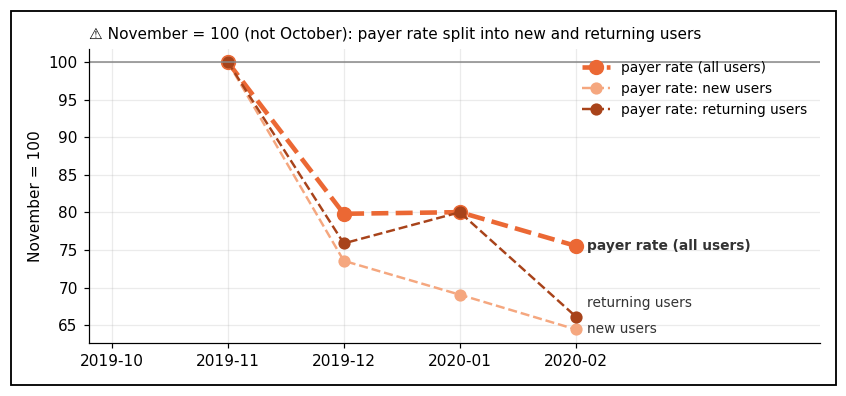

indexed values (November = 100):
month    payer rate (all users)  new users  returning users
2019-11                   100.0      100.0            100.0
2019-12                    79.8       73.6             75.9
2020-01                    80.0       69.1             80.0
2020-02                    75.5       64.4             66.1


In [5]:
rates = pd.DataFrame({
    "payer rate (all users)": tree["payer rate %"].loc[months[1:]],
    "new users": g[("mean", "new")] * 100,
    "returning users": g[("mean", "returning")] * 100,
})
rates_index = rates / rates.iloc[0] * 100
fig, ax = plt.subplots(figsize=(7.5, 3.4))
x = range(1, len(months))   # same x positions as the chart above; October has no split
ax.plot(x, rates_index["payer rate (all users)"], marker="o", markersize=9, linewidth=3, linestyle="--", color=ORANGE, label="payer rate (all users)")
for col, color in [("new users", "#f5a77f"), ("returning users", "#a8431a")]:
    ax.plot(x, rates_index[col], marker="o", markersize=7, linewidth=1.6, linestyle="--", color=color, label=f"payer rate: {col}")
ends = rates_index.iloc[-1].sort_values()
placed = []
for col, v in ends.items():
    y = v if not placed else max(v, placed[-1] + 3.5)
    placed.append(y)
    ax.text(len(months) - 1 + 0.1, y, col, va="center", fontsize=9, color="#333333",
            fontweight="bold" if col.startswith("payer rate") else "normal")
ax.axhline(100, color=GREY, linewidth=1)
ax.set_xticks(range(len(months)), months)
ax.set_xlim(-0.2, len(months) + 1.1)
ax.set_ylabel("November = 100")
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.set_title("⚠ November = 100 (not October): payer rate split into new and returning users", fontsize=10, loc="left")
plt.tight_layout(); plt.show()
print("indexed values (November = 100):")
show(rates_index.round(1).reset_index().rename(columns={"event_month": "month", "index": "month"}))

**Observation:** November's payer rate was higher in **both** groups: new users 6.41% (4.72% in December), returning users 20.84% (15.82% in December). And December had *more* returning users (7,031 vs. 5,436), which on its own would have pushed the overall rate up, not down.

**Observation:** from December on, the overall rate stays above both groups' rates (February: 75.5 vs. 64.4 and 66.1, November = 100), because returning users, who buy more often, make up a growing share of active users each month. Part of that growth comes from how "new user" is defined (Part 0, limit 1).

**Conclusion:** the new-vs-returning mix does not explain the November-to-December drop: the payer rate fell in both groups. Two limits: this is the only mix tested (the log has no traffic source or device to test others), and "new users" in November include more older customers than "new users" in later months (Part 0, limit 1), so the groups aren't quite the same from month to month. December's payer rate (6.82%) matches January's (6.83%), so November is the unusual month.

**Hypothesis:** November's high payer rate comes from a sale (Black Friday fell on 29 November 2019). The log has no price-change or campaign data to confirm it.

**What the tree is for:** when the North Star moves, the tree shows which input moved it, and so which team to ask. For October to November: not marketing (fewer visitors), not loyalty (orders per buyer flat), but the payer rate.

**What the North Star misses:** it says nothing about *why* buyers bought, or how they felt. And it can hide problems in the inputs: two inputs moving in opposite directions can leave the North Star flat.

### Part 2 — HEART

Each row follows the three HEART steps: goal → signal → metric. Where the log has no signal, the row says so.

Definitions of the metrics computed below:
- **Happiness:** not available. The log has no survey or rating.
- **Engagement:** average number of days in the month on which an active user had any event.
- **Adoption:** share of a month's new users who add something to the cart within 7 days of their first event. (7 days is a chosen window: one week covers a full weekly cycle.) November to February only; users first seen after 22 February are left out (limit 2 in Part 0).
- **Retention:** share of a month's active users who are active again the next month. October to January only (limit 2).
- **Task success:** share of sessions with at least one cart add that also contain a purchase. Sessions are the logged `user_session` ids.

In [6]:
ev = query(con, "SELECT user_id, event_type, event_time, event_month, event_date, user_session FROM events_clean")

engagement = ev.groupby(["event_month", "user_id"])["event_date"].nunique().groupby("event_month").mean()

first = ev.groupby("user_id")["event_time"].min().rename("t0")
first_cart = ev[ev["event_type"] == "cart"].groupby("user_id")["event_time"].min().rename("t_cart")
new = pd.concat([first, first_cart], axis=1)
new["month"] = new["t0"].str[:7]
new = new[(new["month"] != "2019-10") & (new["t0"] <= "2020-02-22 23:59:59")]
new["cart_7d"] = (pd.to_datetime(new["t_cart"]) - pd.to_datetime(new["t0"])).dt.total_seconds() <= 7 * 86400
adoption = new.groupby("month")["cart_7d"].mean() * 100

active_sets = ev.groupby("event_month")["user_id"].agg(set)
retention = pd.Series({m: len(active_sets[m] & active_sets[n]) / len(active_sets[m]) * 100
                       for m, n in zip(months[:-1], months[1:])})

sess = ev.dropna(subset=["user_session"]).groupby(["event_month", "user_session"])["event_type"].agg(set)
with_cart = sess[sess.map(lambda s: "cart" in s)]
task = with_cart.map(lambda s: "purchase" in s).groupby("event_month").mean() * 100

heart = pd.DataFrame({"engagement: active days per user": engagement.round(3),
                      "adoption: new users adding to cart in 7 days %": adoption.round(2),
                      "retention: active next month %": retention.round(2),
                      "task success: cart sessions with a purchase %": task.round(2)}).reindex(months)
heart_fmt = heart.apply(lambda col: col.map(lambda v: "n/a" if pd.isna(v) else (f"{v:.3f}" if col.name.startswith("engagement") else f"{v:.2f}")))
show(heart_fmt.reset_index().rename(columns={"index": "month"}))

month    engagement: active days per user  adoption: new users adding to cart in 7 days %  retention: active next month %  task success: cart sessions with a purchase %
2019-10                             1.394                                             n/a                           13.56                                          10.00
2019-11                             1.491                                           21.34                           15.35                                          13.95
2019-12                             1.425                                           17.73                           14.46                                          14.69
2020-01                             1.455                                           17.54                           15.57                                          13.44
2020-02                             1.466                                           17.22                             n/a                                  

| HEART | goal (for this store) | signal | metric | value (range across months) |
|---|---|---|---|---|
| **Happiness** | customers like shopping here | survey answers, ratings | — | **no data**: the log has no survey or rating |
| **Engagement** | customers come back often within a month | days with any event | active days per active user | 1.394 to 1.491 days |
| **Adoption** | new visitors start shopping | first cart add soon after arriving | share of new users adding to cart within 7 days | 17.22% to 21.34% (Nov–Feb) |
| **Retention** | customers return | active again next month | share of active users active again next month | 13.56% to 15.57% (Oct–Jan) |
| **Task success** | customers who start a purchase finish it | a session with a cart add also has a purchase | share of cart sessions with a purchase | 10.00% to 14.69% |

**Observation:** an active user is active on 1.394 to 1.491 days a month, on average, and only 13.56% to 15.57% are active again the next month. Most visitors come briefly and don't return.

**Observation:** of sessions with a cart add, only 10.00% to 14.69% contain a purchase. (This undercounts: a cart add followed by a purchase in a later session counts as a failure here.)

**What HEART misses:** money. None of its five types is revenue or orders, so a feature can score well on HEART and still lose money. And here, one of the five (Happiness) can't be filled at all.

### Part 3 — AARRR (pirate metrics)

The five stages, as a monthly funnel. Definitions:
- **Acquisition:** new users in the month (November to February only, limit 1).
- **Activation:** share of those new users who place an order within 7 days of their first event (7 days chosen, as in Part 2; users first seen after 22 February left out). Module 4 covers how to choose an activation definition properly.
- **Retention (buyers):** share of a month's buyers who buy again the next month (October to January only). Not the same as HEART's Retention (Part 2), which counts any activity.
- **Referral:** no data (the log has no referral or invite event).
- **Revenue:** gross revenue in the month (Module 1's definition).

In [7]:
orders_df = query(con, "SELECT user_id, event_time, event_month FROM orders")
first_order = orders_df.groupby("user_id")["event_time"].min().rename("t_order")
new = new.join(first_order)
new["order_7d"] = (pd.to_datetime(new["t_order"]) - pd.to_datetime(new["t0"])).dt.total_seconds() <= 7 * 86400
activation = new.groupby("month")["order_7d"].mean() * 100

buyer_sets = orders_df.groupby("event_month")["user_id"].agg(set)
buyer_retention = pd.Series({m: len(buyer_sets[m] & buyer_sets[n]) / len(buyer_sets[m]) * 100
                             for m, n in zip(months[:-1], months[1:])})
revenue = pd.Series({m: metric(con, "revenue", m + "-01", month_end[m]) for m in months})

aarrr = pd.DataFrame({"acquisition: new users": blocks["new_users"].where(blocks["new_users"] >= 0),
                      "activation: order in 7 days %": activation.round(2),
                      "retention: buyers buying next month %": buyer_retention.round(2),
                      "referral": "no data",
                      "revenue": revenue.round(0)}).reindex(months)
fmt = pd.DataFrame({
    "acquisition: new users": aarrr["acquisition: new users"].map(lambda v: "n/a" if pd.isna(v) else f"{v:,.0f}"),
    "activation: order in 7 days %": aarrr["activation: order in 7 days %"].map(lambda v: "n/a" if pd.isna(v) else f"{v:.2f}"),
    "retention: buyers buying next month %": aarrr["retention: buyers buying next month %"].map(lambda v: "n/a" if pd.isna(v) else f"{v:.2f}"),
    "referral": aarrr["referral"],
    "revenue": aarrr["revenue"].map("{:,.0f}".format)})
show(fmt.reset_index().rename(columns={"index": "month"}))

month    acquisition: new users  activation: order in 7 days %  retention: buyers buying next month %  referral  revenue
2019-10                     n/a                            n/a                                  17.63  no data   114,457
2019-11                  31,421                           5.84                                  13.70  no data   153,550
2019-12                  30,136                           4.45                                  15.36  no data   107,917
2020-01                  33,029                           4.12                                  14.88  no data   127,663
2020-02                  29,586                           3.84                                    n/a  no data   122,476


**One cohort through the funnel.** The table above mixes different groups at each stage. The chart below follows a single cohort instead: users first seen in November 2019, followed to the end of the data (29 February 2020).
- **Acquisition:** all users first seen in November
- **Activation:** of those, users who ordered within 7 days of their first event
- **Retention (buyers):** of the activated, users who placed a second order by 29 February
- **Referral:** no data
- **Revenue:** shown as a number under the chart, not a bar, because it is money, not users

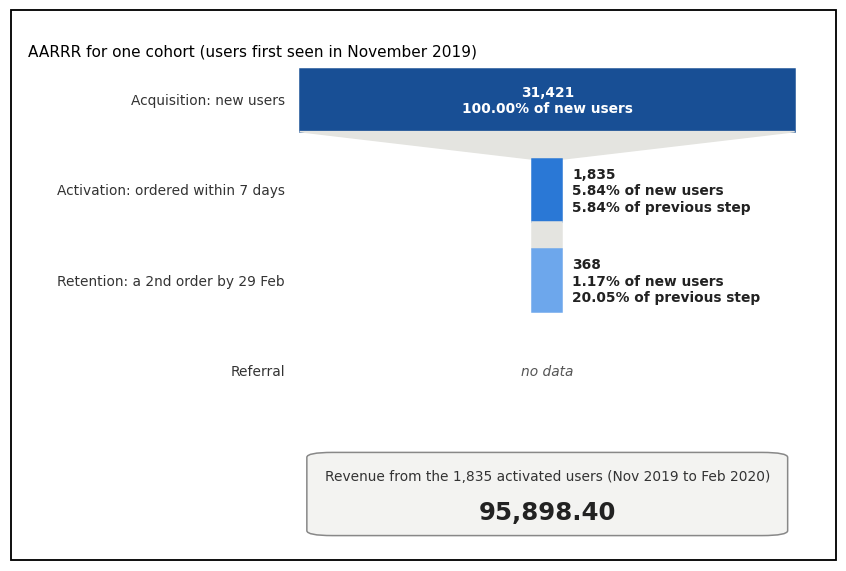

step by step:
  activation = 1,835 / 31,421 = 5.84%
  retention  = 368 / 1,835 = 20.05% of the activated
  revenue from the activated users, November to February: 95,898.40


In [8]:
from matplotlib.patches import Polygon, FancyBboxPatch

cohort = new[new["month"] == "2019-11"]
activated = cohort[cohort["order_7d"]]
cohort_orders = orders_df[orders_df["user_id"].isin(activated.index)].groupby("user_id").size()
stages = pd.Series({"Acquisition: new users": len(cohort),
                    "Activation: ordered within 7 days": len(activated),
                    "Retention: a 2nd order by 29 Feb": int((cohort_orders >= 2).sum())})
rev = query(con, "SELECT user_id, revenue FROM orders")
activated_revenue = rev[rev["user_id"].isin(activated.index)]["revenue"].sum()

# Funnel: each stage a centred bar whose width is its count; grey trapezoids connect the stages.
# Small stages get a minimum drawn width so they stay visible (the printed numbers are exact).
fig = plt.figure(figsize=(7.5, 5.0))
ax = fig.add_axes([0.02, 0.28, 0.96, 0.62])
ramp = ["#184f95", "#2a78d6", "#6da7ec"]
top = stages.iloc[0]
widths = [max(v / top, 0.06) for v in stages.values]
h, gap = 0.8, 0.35
for k, ((name, v), w, color) in enumerate(zip(stages.items(), widths, ramp)):
    y0 = -k * (h + gap)
    ax.add_patch(plt.Rectangle((-w / 2, y0 - h), w, h, color=color))
    ax.text(-0.53, y0 - h / 2, name, ha="right", va="center", fontsize=9, color="#333333")
    prev = "" if k == 0 else f"\n{v / stages.iloc[k - 1]:.2%} of previous step"
    label = f"{v:,}\n{v / top:.2%} of new users{prev}"
    if w >= 0.6:
        ax.text(0, y0 - h / 2, label, ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    else:
        ax.text(w / 2 + 0.02, y0 - h / 2, label, ha="left", va="center", fontsize=9, color="#222222", fontweight="bold")
    if k < len(stages) - 1:
        wn = widths[k + 1]
        ax.add_patch(Polygon([(-w / 2, y0 - h), (w / 2, y0 - h), (wn / 2, y0 - h - gap), (-wn / 2, y0 - h - gap)],
                             color="#e4e4e0"))
y_ref = -len(stages) * (h + gap)
ax.text(-0.53, y_ref - h / 2, "Referral", ha="right", va="center", fontsize=9, color="#333333")
ax.text(0, y_ref - h / 2, "no data", ha="center", va="center", fontsize=9, color="#555555", style="italic")
ax.set_xlim(-1.05, 0.55); ax.set_ylim(y_ref - h - 0.05, 0.05)
ax.axis("off")
ax.set_title("AARRR for one cohort (users first seen in November 2019)", fontsize=10, loc="left")

# Revenue as a KPI box under the funnel: money, not users, so it is not a funnel bar.
kpi = fig.add_axes([0.34, 0.03, 0.62, 0.18]); kpi.axis("off")
kpi.add_patch(FancyBboxPatch((0.03, 0.08), 0.94, 0.84, boxstyle="round,pad=0.0,rounding_size=0.05", facecolor="#f3f3f1",
                             edgecolor="#888888", linewidth=1, transform=kpi.transAxes, clip_on=False))
kpi.text(0.5, 0.68, "Revenue from the 1,835 activated users (Nov 2019 to Feb 2020)", ha="center", va="center",
         fontsize=9, color="#333333", transform=kpi.transAxes)
kpi.text(0.5, 0.32, f"{activated_revenue:,.2f}", ha="center", va="center", fontsize=16, fontweight="bold",
         color="#222222", transform=kpi.transAxes)
plt.show()
print("step by step:")
print(f"  activation = {len(activated):,} / {len(cohort):,} = {len(activated) / len(cohort):.2%}")
print(f"  retention  = {int((cohort_orders >= 2).sum()):,} / {len(activated):,} = {(cohort_orders >= 2).sum() / len(activated):.2%} of the activated")
print(f"  revenue from the activated users, November to February: {activated_revenue:,.2f}")

**Observation:** of 31,421 users first seen in November, 1,835 (5.84%) ordered within 7 days, and 368 of those (20.05%) placed a second order by 29 February. The biggest loss is the first step: 94.16% of the cohort (100% − 5.84%) did not order in its first week.

**Observation, the biggest loss is Activation:** only 3.84% to 5.84% of new users place an order within their first 7 days (November to February). Acquisition brings 29,586 to 33,029 new users a month, so at least 94.16% of them (100% − 5.84%) place no order in their first 7 days.

**Observation:** of a month's buyers, 13.70% to 17.63% buy again the next month.

**Observation, a trend to watch:** activation falls every month: 5.84% (November), 4.45%, 4.12%, 3.84% (February). Four months are too few to call it a trend, and part of the fall may come from how "new user" is defined (Part 0, limit 1): November's "new" group includes more older customers.

**What AARRR misses:** the experience (no Happiness, no Task success), and stages the log can't see (here Referral). It also treats stages as one straight line, though real customers skip and repeat stages.

### Part 4 — OKRs: turning a metric into a target

An OKR takes one metric from a framework and adds a starting value, a target and a deadline. Using Part 3's weakest stage:

| part | example |
|---|---|
| **Objective** (goal in words) | Turn first-time visitors into buyers. |
| **Key result 1** | Raise Activation (new users ordering within 7 days) from 3.84% (February) to 4.50% by the end of the quarter (Part 3). |
| **Key result 2** | Raise Task success (cart sessions with a purchase) from 12.40% (February) to 14.00% by the end of the quarter (Part 2). |

The starting values come from the data (Parts 2 and 3). **The targets, 4.50% and 14.00%, are chosen examples** to show the format, not recommendations; a real team sets them from what it thinks is achievable.

**What OKRs miss:** they say nothing about which metric to choose. That comes from a framework. They can also push a team to hit the number in ways that hurt something else, which is why experiments add guardrails (Part 5).

### Part 5 — Primary metric plus guardrails (recap)

**Covered in:** Product Analytics Case Study, [`05_Metrics_Framework_and_Synthesis.ipynb`](https://github.com/omri-sabag83/Product-Analytics-Case-Study/blob/main/05_Metrics_Framework_and_Synthesis.ipynb), section "Framework summary". That project analysed an online-learning platform (students and courses), and built this setup:

| role | metric | value there |
|---|---|---|
| **primary** | Week-2 Activation Rate (share of enrollments active on 3 or more days in their first 14 days) | 61.7% of 32,593 enrollments |
| **guardrail 1** | assessment completion rate (share of available assessments submitted); the source reports it for activated vs. not activated enrollments | 67.7% vs. 32.1% |
| **guardrail 2** | gap in activation rate between the poorest and richest areas | 12.5 percentage points (54.8% vs. 67.3%) |
| **guardrail 3** | activated enrollments still active from week 20 on | about 52% to 64% |

**The idea in one line:** move the primary metric, but stop if a guardrail gets worse by more than a limit agreed in advance. For the theory (including the OEC, Overall Evaluation Criterion), see the A/B Testing Playbook's Module 4, linked in the Lesson.

### Part 6 — The frameworks side by side

In [9]:
compare = pd.DataFrame([
    ["North Star", "Is the product delivering value?", "1 metric + 3-5 inputs", "how users feel; problems that cancel out", "aligning the whole company on one number"],
    ["HEART", "Is the experience good?", "5 types: goal -> signal -> metric", "money (no revenue type)", "measuring a product or a feature's experience"],
    ["AARRR", "Where do we lose customers?", "5 lifecycle stages", "experience; non-linear journeys", "finding the weakest stage of the customer life"],
    ["OKRs", "What exactly will we achieve this quarter?", "objective + a few key results", "which metric to pick", "turning a chosen metric into a target"],
    ["Primary + guardrails", "Did this change work, safely?", "1 primary + a few guardrails", "metrics not chosen as guardrails; effects after the test ends", "deciding an A/B test"],
], columns=["framework", "answers", "made of", "misses", "use it for"])
show(compare)

framework             answers                                     made of                            misses                                                         use it for
North Star            Is the product delivering value?            1 metric + 3-5 inputs              how users feel; problems that cancel out                       aligning the whole company on one number
HEART                 Is the experience good?                     5 types: goal -> signal -> metric  money (no revenue type)                                        measuring a product or a feature's experience
AARRR                 Where do we lose customers?                 5 lifecycle stages                 experience; non-linear journeys                                finding the weakest stage of the customer life
OKRs                  What exactly will we achieve this quarter?  objective + a few key results      which metric to pick                                           turning a chosen metric into a targ

**Conclusion:** the frameworks are not rivals; they answer different questions. Applied to the same store:
- the **North Star** tree located November's jump in orders: the payer rate rose (6.10% to 8.54%);
- **HEART** showed that the experience can be measured on 4 of its 5 types, and that Happiness has no data at all;
- **AARRR** located the biggest loss: only 3.84% to 5.84% of new users order within a week;
- **OKRs** turned the weakest number into a target.

## Exercises

### Exercise 1 — Which framework?

**The question:** three requests reach the analytics team. For each, which framework fits, and what can't it see in this store's data?
1. The CEO: "Every team reports a different success number. Which one should we all watch?"
2. The design team: "We redesigned the product page. Is the experience better?"
3. The growth team: "Ad spend is up and visitors arrive, but sales are flat. What's going on?"

**Step 1, match each request to the question a framework answers** (Part 6's "answers" column):
1. One shared success number → **North Star** ("Is the product delivering value?").
2. Is the experience better → **HEART** ("Is the experience good?").
3. Visitors arrive but don't become sales: customers are lost somewhere between arriving and paying → **AARRR** ("Where do we lose customers?").

**Step 2, fill each with this store's numbers:**
1. **North Star:** monthly orders, with the tree active users × payer rate × orders per buyer (Part 1).
2. **HEART:** compare the four measurable types before and after the redesign, especially task success (cart sessions with a purchase: 10.00% to 14.69% so far).
3. **AARRR:** acquisition is not the problem (29,586 to 33,029 new users a month); activation is (3.84% to 5.84% order within 7 days).

**Step 3, what each can't see here:**
1. North Star: why November's payer rate jumped (no campaign or price data).
2. HEART: Happiness (no survey).
3. AARRR: Referral (no referral event), and which ad channel each visitor came from (no traffic source).

### Exercise 2 — Read a North Star movement

**The question:** orders fell from January (3,268) to February (2,961). Which input moved?

**Step 1, the inputs for both months** (Part 1's table):
- active users: 41,105 → 38,943
- payer rate: 6.83% → 6.45%
- orders per buyer: 1.163 → 1.179

**Step 2, the change in each input, as a ratio February ÷ January:**
- active users: 38,943 ÷ 41,105 = 0.947, i.e. 5.3% lower
- payer rate: 6.45 ÷ 6.83 = 0.944, i.e. 5.6% lower
- orders per buyer: 1.179 ÷ 1.163 = 1.014, i.e. 1.4% higher

**Step 3, the answer:** two inputs fell by about the same amount: fewer active users and a lower payer rate, each about 5%. Orders per buyer rose slightly (by 1.4%), which softened the drop: from 10.6% (0.947 × 0.944 = 0.894) to 9.4% (0.894 × 1.014 = 0.906). Unlike November, no single input explains the move; both the marketing team (visitors) and the conversion side (payer rate) are involved.

## Key takeaways

- **Observation:** each framework could be filled only partly from this log: no Happiness (no survey), no Referral (no referral event), no traffic source. Saying "no data" is part of using a framework honestly.
- **Observation:** North Star tree: orders = active users × payer rate × orders per buyer, exactly. November's jump in orders (2,841 → 3,687) came from the payer rate (6.10% → 8.54%), not from more visitors.
- **Hypothesis:** November's higher payer rate came from a sale or campaign. The log can't confirm it.
- **Observation:** AARRR: the weakest stage is activation: 3.84% to 5.84% of new users order within 7 days.
- **Observation:** HEART: 13.56% to 15.57% of active users return the next month, and 10.00% to 14.69% of sessions with a cart add contain a purchase.
- **Conclusion:** the frameworks answer different questions (Part 6); the request decides which one to use, not habit.
- **Data limits, carried forward:** new users can't be measured for October 2019, and windows at the end of February are cut short. Module 5 (retention) meets the same limit.